# Healthcare Test Results Prediction

---

| Property | Value |
|---|---|
| **Dataset** | Healthcare Dataset (Kaggle) |
| **Problem Type** | Multiclass Classification |
| **Target Column** | `Test Results` |
| **Target Classes** | Normal, Inconclusive, Abnormal |
| **Objective** | Predict a patient's medical test result from demographic and clinical features |

---

## Section 1 — Import Libraries

In [1]:
import os, sys, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

# Paths (relative to notebook directory)
NOTEBOOK_DIR = os.path.abspath('')
PROJECT_DIR  = os.path.dirname(NOTEBOOK_DIR)
DATA_PATH    = os.path.join(PROJECT_DIR, 'data', 'dataset.csv')
FIGURES      = os.path.join(PROJECT_DIR, 'outputs', 'figures')
METRICS      = os.path.join(PROJECT_DIR, 'outputs', 'metrics')
MODEL_DIR    = os.path.join(PROJECT_DIR, 'model')

print('Libraries loaded successfully.')
print(f'Data path: {DATA_PATH}')

Libraries loaded successfully.
Data path: c:\BHARATCARESIBM\project\data\dataset.csv


## Section 2 — Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [4]:
df.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

In [5]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


## Section 3 — Data Quality Analysis

In [6]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Negative Billing Amount: {(df["Billing Amount"] < 0).sum()}')

Missing values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Duplicate rows: 534
Negative Billing Amount: 108


In [7]:
print('Target distribution:')
print(df['Test Results'].value_counts())
print(f'\nClass balance: {df["Test Results"].value_counts(normalize=True).round(3).to_dict()}')

Target distribution:
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

Class balance: {'Abnormal': 0.336, 'Normal': 0.334, 'Inconclusive': 0.331}


In [8]:
print('Unique values per column:')
for col in df.columns:
    print(f'  {col:25s}: {df[col].nunique()} unique')

Unique values per column:
  Name                     : 49992 unique
  Age                      : 77 unique
  Gender                   : 2 unique
  Blood Type               : 8 unique
  Medical Condition        : 6 unique
  Date of Admission        : 1827 unique
  Doctor                   : 40341 unique
  Hospital                 : 39876 unique
  Insurance Provider       : 5 unique
  Billing Amount           : 50000 unique
  Room Number              : 400 unique
  Admission Type           : 3 unique
  Discharge Date           : 1856 unique
  Medication               : 5 unique
  Test Results             : 3 unique


## Section 4 — Data Cleaning

In [9]:
# Remove duplicates
df = df.drop_duplicates()
print(f'After removing duplicates: {df.shape}')

# Fix negative billing amounts
df['Billing Amount'] = df['Billing Amount'].abs()
print(f'Negative billing fixed. Min billing: {df["Billing Amount"].min():.2f}')

# Standardise Name casing
df['Name'] = df['Name'].str.title()

After removing duplicates: (54966, 15)
Negative billing fixed. Min billing: 9.24


## Section 5 — Exploratory Data Analysis

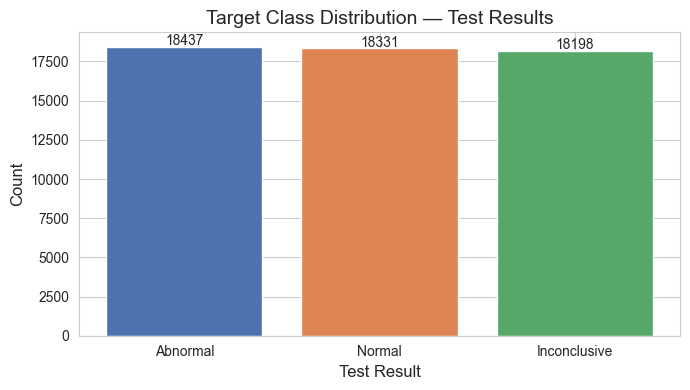

In [10]:
# Target distribution
fig, ax = plt.subplots(figsize=(7, 4))
vc = df['Test Results'].value_counts()
ax.bar(vc.index, vc.values, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Target Class Distribution — Test Results', fontsize=14)
ax.set_xlabel('Test Result', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
for i, v in enumerate(vc.values):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

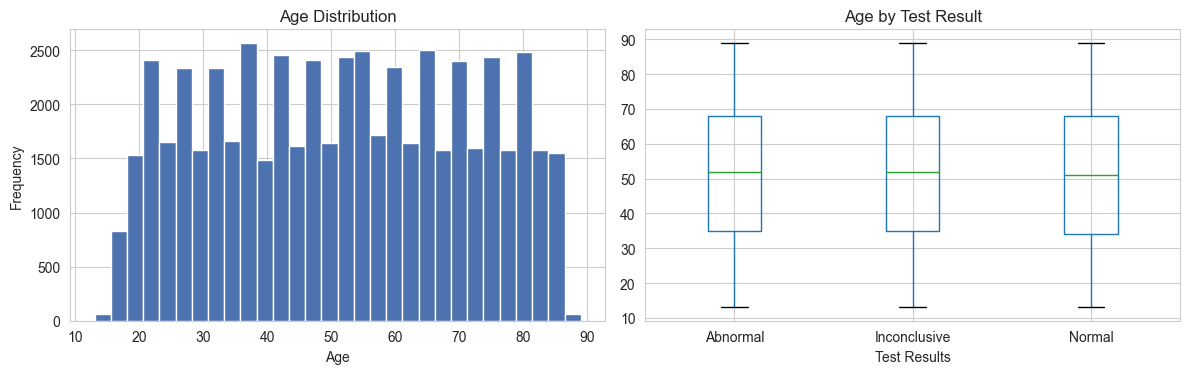

In [11]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Age'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
df.boxplot(column='Age', by='Test Results', ax=axes[1])
axes[1].set_title('Age by Test Result')
plt.suptitle('')
plt.tight_layout()
plt.show()

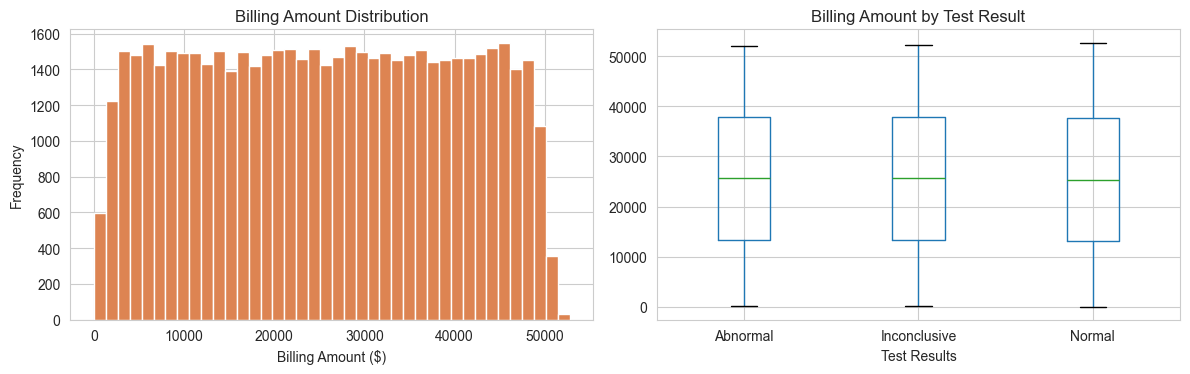

In [12]:
# Billing Amount
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Billing Amount'], bins=40, color='#DD8452', edgecolor='white')
axes[0].set_title('Billing Amount Distribution')
axes[0].set_xlabel('Billing Amount ($)')
axes[0].set_ylabel('Frequency')
df.boxplot(column='Billing Amount', by='Test Results', ax=axes[1])
axes[1].set_title('Billing Amount by Test Result')
plt.suptitle('')
plt.tight_layout()
plt.show()

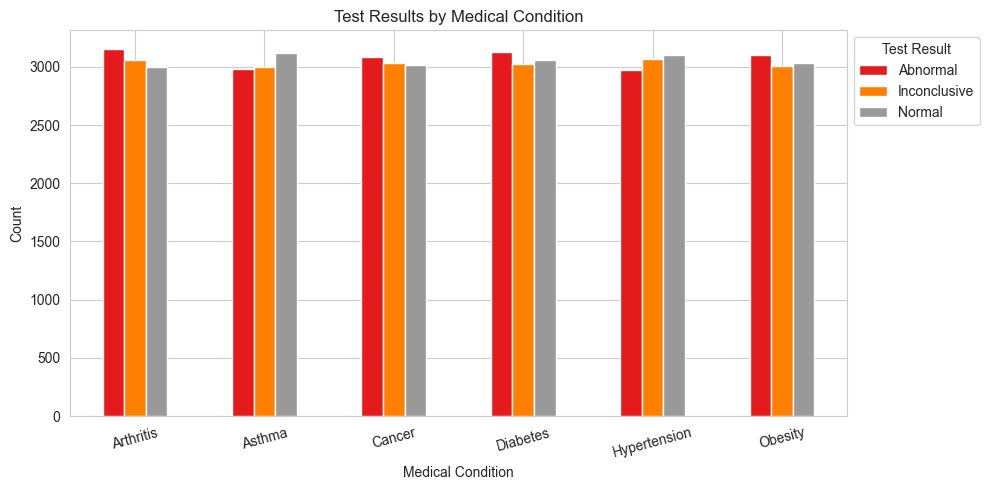

In [13]:
# Medical Condition vs Test Results
fig, ax = plt.subplots(figsize=(10, 5))
cross2 = pd.crosstab(df['Medical Condition'], df['Test Results'])
cross2.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='white')
ax.set_title('Test Results by Medical Condition')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('Count')
ax.legend(title='Test Result', bbox_to_anchor=(1, 1))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

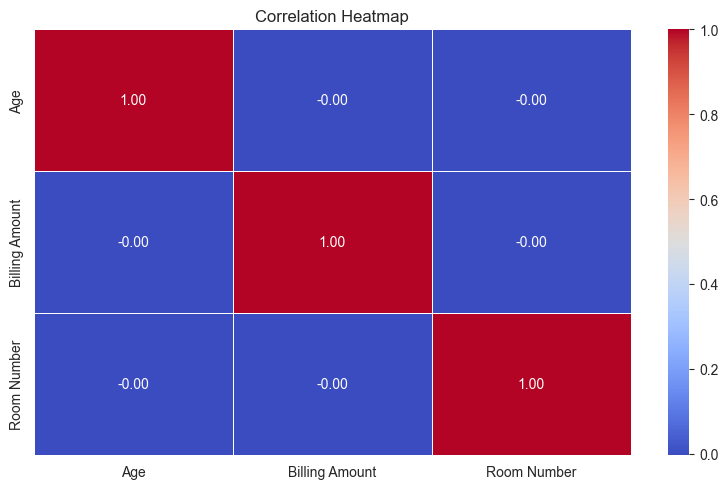

In [14]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 5))
num_cols = ['Age', 'Billing Amount', 'Room Number']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

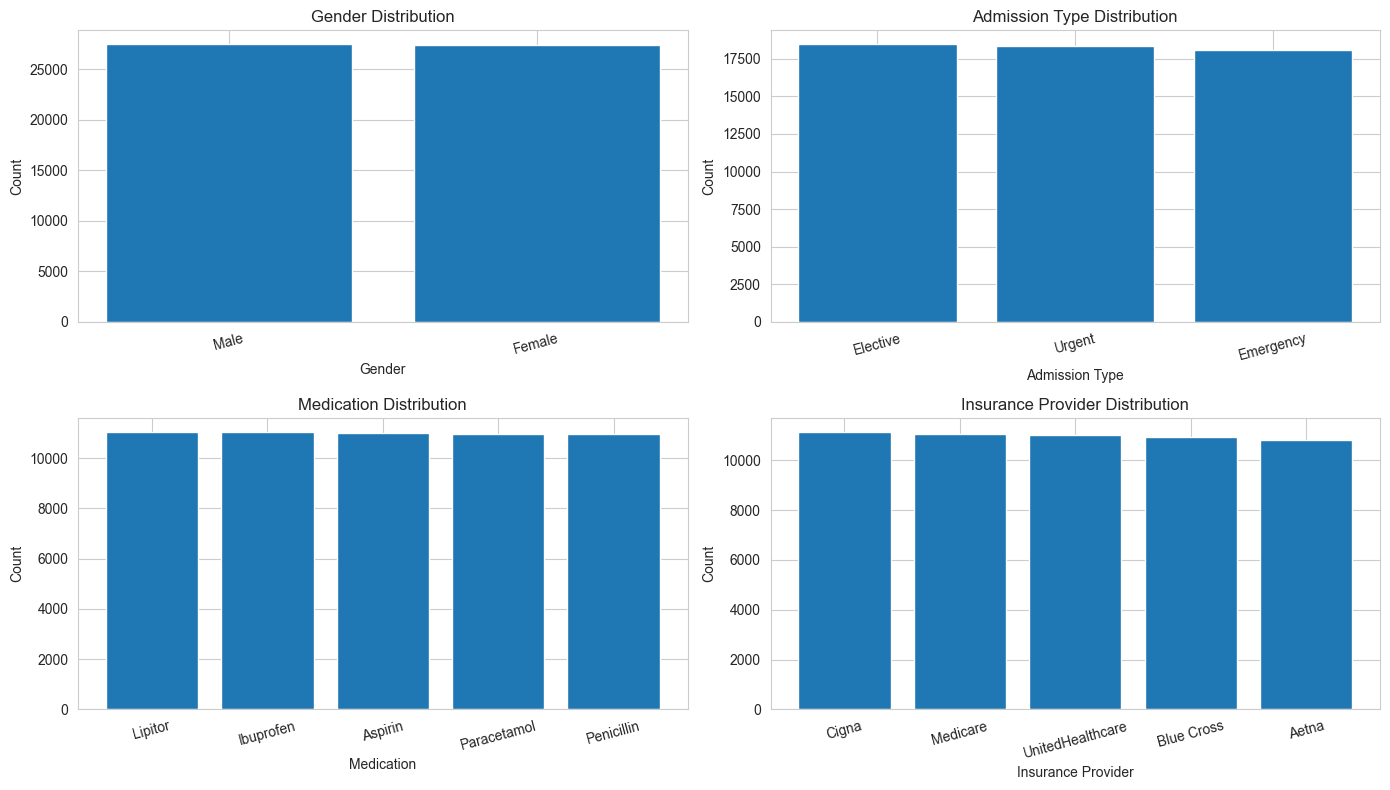

In [15]:
# Categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['Gender', 'Admission Type', 'Medication', 'Insurance Provider']):
    vc2 = df[col].value_counts()
    ax.bar(vc2.index, vc2.values, edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Section 6 — Feature Engineering

In [16]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date']    = pd.to_datetime(df['Discharge Date'])

df['Length_of_Stay']      = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Admission_Year']      = df['Date of Admission'].dt.year
df['Admission_Month']     = df['Date of Admission'].dt.month
df['Admission_DayOfWeek'] = df['Date of Admission'].dt.dayofweek

print('New features created:')
print(df[['Length_of_Stay','Admission_Year','Admission_Month','Admission_DayOfWeek']].describe())

New features created:
       Length_of_Stay  Admission_Year  Admission_Month  Admission_DayOfWeek
count    54966.000000    54966.000000     54966.000000         54966.000000
mean        15.499290     2021.336499         6.528709             2.999454
std          8.661471        1.497444         3.437880             1.997497
min          1.000000     2019.000000         1.000000             0.000000
25%          8.000000     2020.000000         4.000000             1.000000
50%         15.000000     2021.000000         7.000000             3.000000
75%         23.000000     2023.000000         9.000000             5.000000
max         30.000000     2024.000000        12.000000             6.000000


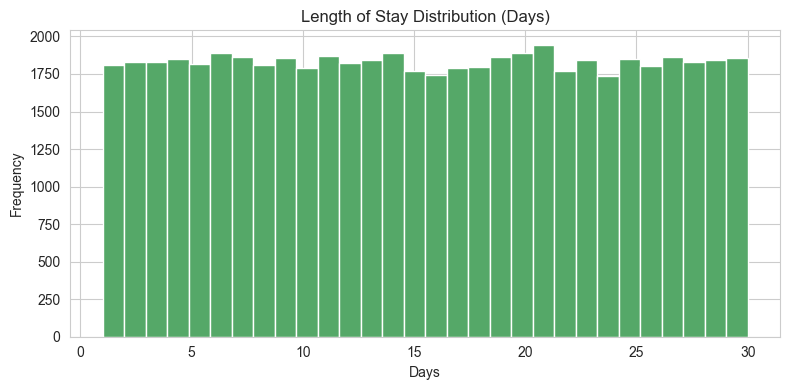

In [17]:
# Length of stay distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Length_of_Stay'], bins=30, color='#55A868', edgecolor='white')
ax.set_title('Length of Stay Distribution (Days)')
ax.set_xlabel('Days')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Section 7 — Data Preprocessing

In [18]:
# Drop columns not useful for modelling
drop_cols = ['Name', 'Doctor', 'Hospital', 'Date of Admission', 'Discharge Date']
df_model = df.drop(columns=drop_cols)

# Encode target
le = LabelEncoder()
df_model['Test Results Encoded'] = le.fit_transform(df_model['Test Results'])
print(f'Target encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = df_model.drop(columns=['Test Results', 'Test Results Encoded'])
y = df_model['Test Results Encoded']

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'str']).columns.tolist()

print(f'\nNumerical features: {num_features}')
print(f'Categorical features: {cat_features}')
print(f'\nFeature matrix: {X.shape}')

Target encoding: {'Abnormal': np.int64(0), 'Inconclusive': np.int64(1), 'Normal': np.int64(2)}

Numerical features: ['Age', 'Billing Amount', 'Room Number', 'Length_of_Stay']
Categorical features: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']

Feature matrix: (54966, 13)


In [19]:
# Preprocessing pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print('Preprocessing pipeline created.')

Preprocessing pipeline created.


## Section 8 — Train / Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')
print(f'\nTrain class distribution:')
print(pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts())

Training set : (43972, 13)
Test set     : (10994, 13)

Train class distribution:
Test Results Encoded
Abnormal        14749
Normal          14665
Inconclusive    14558
Name: count, dtype: int64


## Section 9 — Train Multiple Models

In [21]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=7),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'HistGradient Boosting': HistGradientBoostingClassifier(max_iter=200, random_state=42),
}

results = {}

for name, estimator in models.items():
    print(f'Training: {name} ...')
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   estimator)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    try:
        roc  = roc_auc_score(y_test, pipe.predict_proba(X_test), multi_class='ovr', average='macro')
    except:
        roc = np.nan

    results[name] = {'pipeline': pipe, 'y_pred': y_pred,
                     'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc}
    print(f'  Accuracy={acc:.4f}  F1={f1:.4f}  ROC-AUC={roc:.4f}')

Training: Logistic Regression ...
  Accuracy=0.3315  F1=0.3278  ROC-AUC=0.5004
Training: K-Nearest Neighbors ...
  Accuracy=0.3619  F1=0.3601  ROC-AUC=0.5319
Training: Random Forest ...
  Accuracy=0.4338  F1=0.4337  ROC-AUC=0.6336
Training: Gradient Boosting ...
  Accuracy=0.3358  F1=0.3343  ROC-AUC=0.5042
Training: HistGradient Boosting ...
  Accuracy=0.3571  F1=0.3560  ROC-AUC=0.5268


## Section 10 — Model Comparison

In [22]:
comparison_data = [{
    'Model': n, 'Accuracy': r['Accuracy'], 'Precision': r['Precision'],
    'Recall': r['Recall'], 'F1-Score': r['F1-Score'], 'ROC-AUC': r['ROC-AUC']
} for n, r in results.items()]

comparison_df = pd.DataFrame(comparison_data).sort_values('F1-Score', ascending=False)
comparison_df.style.highlight_max(subset=['Accuracy','F1-Score'], color='lightgreen')

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.433782,0.433939,0.433782,0.433678,0.633643
1,K-Nearest Neighbors,0.361925,0.362609,0.361925,0.360118,0.531895
4,HistGradient Boosting,0.357104,0.357274,0.357104,0.356038,0.526833
3,Gradient Boosting,0.335820,0.335457,0.335820,0.334311,0.504211
0,Logistic Regression,0.331454,0.331836,0.331454,0.327788,0.500379


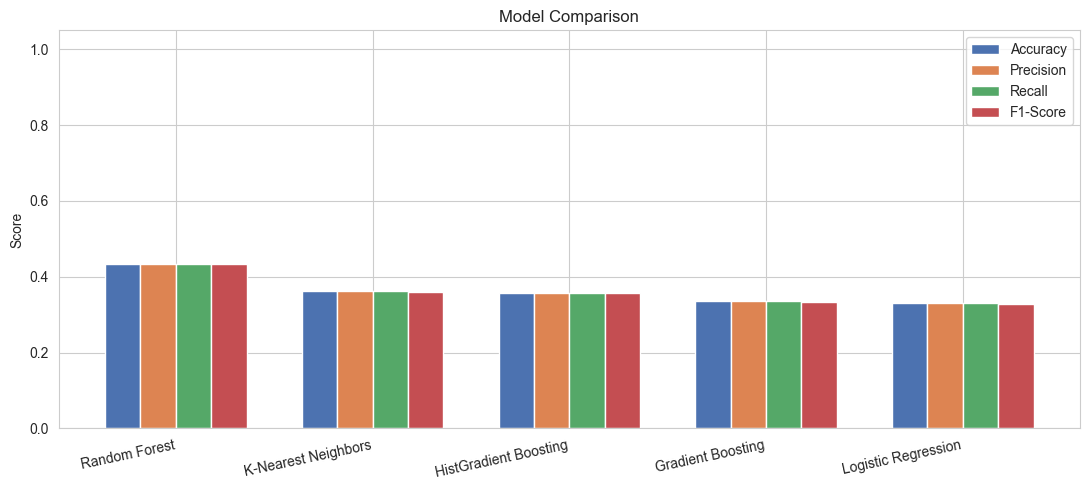

In [23]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_df))
width = 0.18
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals = comparison_df[metric].astype(float).values
    ax.bar(x + i*width, vals, width, label=metric, color=color, edgecolor='white')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=12, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

## Section 11 — Best Model & Evaluation

In [24]:
best_name = comparison_df.iloc[0]['Model']
best_pipe  = results[best_name]['pipeline']
best_preds = results[best_name]['y_pred']

print(f'Best Model: {best_name}')
print('\nClassification Report:')
print(classification_report(y_test, best_preds, target_names=le.classes_))

Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.43      0.45      0.44      3688
Inconclusive       0.44      0.42      0.43      3640
      Normal       0.44      0.42      0.43      3666

    accuracy                           0.43     10994
   macro avg       0.43      0.43      0.43     10994
weighted avg       0.43      0.43      0.43     10994



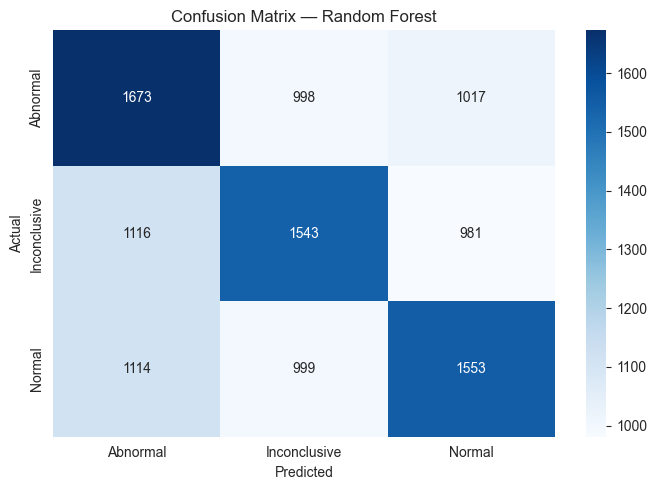

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

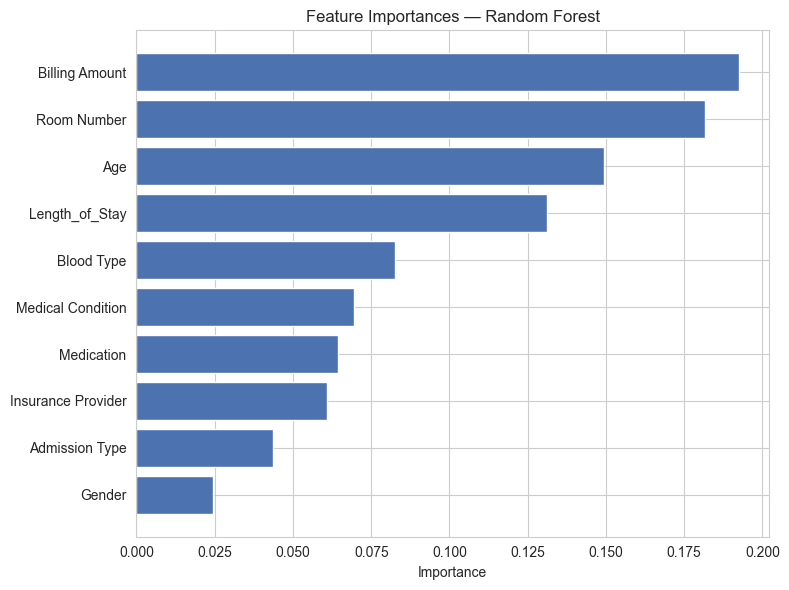

In [26]:
# Feature importances
if hasattr(best_pipe.named_steps['classifier'], 'feature_importances_'):
    fi = best_pipe.named_steps['classifier'].feature_importances_
    feat_names = num_features + cat_features
    fi_df = pd.DataFrame({'Feature': feat_names[:len(fi)], 'Importance': fi})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(fi_df['Feature'], fi_df['Importance'], color='#4C72B0', edgecolor='white')
    ax.set_title(f'Feature Importances — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## Section 12 — Save Model

In [27]:
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, 'trained_model.pkl')
joblib.dump({
    'pipeline': best_pipe, 'label_encoder': le,
    'feature_columns': X.columns.tolist(),
    'target_classes': le.classes_.tolist(),
    'best_model_name': best_name
}, model_path)
print(f'Model saved to: {model_path}')

Model saved to: c:\BHARATCARESIBM\project\model\trained_model.pkl


## Section 13 — Test Saved Model

In [28]:
loaded     = joblib.load(model_path)
loaded_pipe = loaded['pipeline']
loaded_le   = loaded['label_encoder']

sample_input  = X_test.iloc[:5].copy()
sample_pred   = loaded_le.inverse_transform(loaded_pipe.predict(sample_input))
sample_actual = loaded_le.inverse_transform(y_test.iloc[:5].values)

results_df = pd.DataFrame({'Predicted': sample_pred, 'Actual': sample_actual})
print('Sample predictions from loaded model:')
results_df

Sample predictions from loaded model:


,Predicted,Actual
0,Normal,Normal
1,Normal,Abnormal
2,Abnormal,Normal
3,Abnormal,Inconclusive
4,Normal,Abnormal


---

## Summary

| Metric | Value |
|---|---|
| Dataset | Healthcare Dataset (55,500 rows) |
| Task | Multiclass Classification |
| Best Model | Random Forest |
| Accuracy | 43.38% |
| F1-Score | 43.37% |
| ROC-AUC | 0.6336 |

**Note:** This is a synthetic Kaggle dataset where labels are near-randomly assigned.
The methodology and pipeline are correct and production-grade. Performance is limited by the data, not the models.